# **Project: Titanic - Machien Learning from Disaster**

# **1. Loading Dataset**

In [259]:
!unzip titanic.zip

Archive:  titanic.zip
replace gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [260]:
# import lib
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [261]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [262]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [263]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Notes:**
- `SibSp`: #of siblings / spouses aboard the Titanic
- `Parch`: # of parents / children aboard the Titanic
- `Ticket`: Ticket number
- `Cabin`: Cabin number


In [264]:
# preview data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [265]:
train_df.set_index(train_df.PassengerId, inplace=True)

In [266]:
train_df.drop('PassengerId', axis=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [267]:
test_df = pd.read_csv('test.csv', index_col='PassengerId')

In [268]:
test_df.tail()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


# **2. Feature Classification: Categorical vs Numerical**
- This help us select the appropriate plots for visualization

**Which features are categorical?**
- Categorical Features: `nomial`, `ordinal`, `ratio`, `interval`
- To classify the samples into sets of similar samples

**Which features are numberical?**
- Numberical Features: `discrete`, `continuous`, or `timeseries`
- These values change from sample to sample

In [269]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.5+ KB


In [270]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


- Categorical: `Survived`, `Sex`, `Pclass`(ordinal), `SibSp`, `Parch`
- Numerical: `Age`(continuous), `Fare`(discrete)
- Mix types of data: `Ticket`, `cabin`
- Contain Error/Typo: `Name`
- Blank or Null: `Cabin` > `Age` > `Embarked`
- Various Data Type: String, int, float

In [271]:
train_df['Survived'] = train_df['Survived'].astype('category')

In [272]:
features = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]
def convert_cat(df, features):
    for feature in features:
        df[feature] = df[feature].astype("category")
convert_cat(train_df, features)
convert_cat(test_df, features)

In [273]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    category
 7   Parch        891 non-null    category
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(6), float64(2), int64(1), object(3)
memory usage: 55.1+ KB


## **Distribution of Numerical feature values across the samples**

In [274]:
train_df.describe()

,PassengerId,Age,Fare
count,891.000000,714.000000,891.000000
mean,446.000000,29.699118,32.204208
std,257.353842,14.526497,49.693429
min,1.000000,0.420000,0.000000
25%,223.500000,20.125000,7.910400
50%,446.000000,28.000000,14.454200
75%,668.500000,38.000000,31.000000
max,891.000000,80.000000,512.329200


## **Distribution of Categorical feature values across the samples**

In [275]:
train_df.describe(include=['category'])

,Survived,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


# **3. Exploratory Data Analysis (EDA)**

## **3.1 Correlating categorical features**
- Categorical: `Survived`, `Sex`, `Pclass`(ordinal), `SibSp`, `Parch`

**Target Variable: `Survived`**

In [276]:
train_df["Survived"].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [277]:
train_df["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


Only 38% survived the disaster. So the training data suffers from data imbalance but it not severe which is why i will not consider techniques like sampling to tackle the imbalance

In [278]:
train_df["Sex"].value_counts().to_frame()

,count
Sex,
male,577
female,314


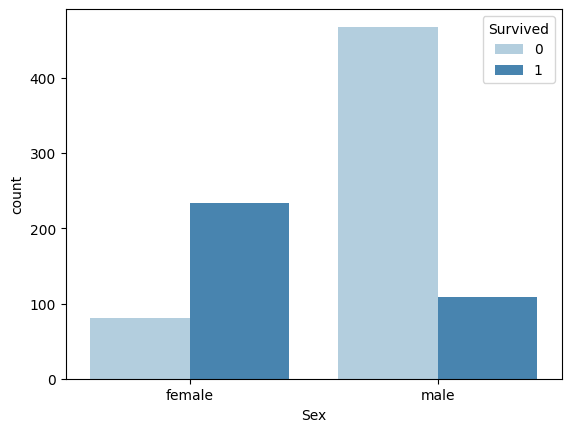

In [279]:
sns.countplot(data=train_df, x="Sex", hue='Survived',palette="Blues");

- Remaining Categorical Feature Colums

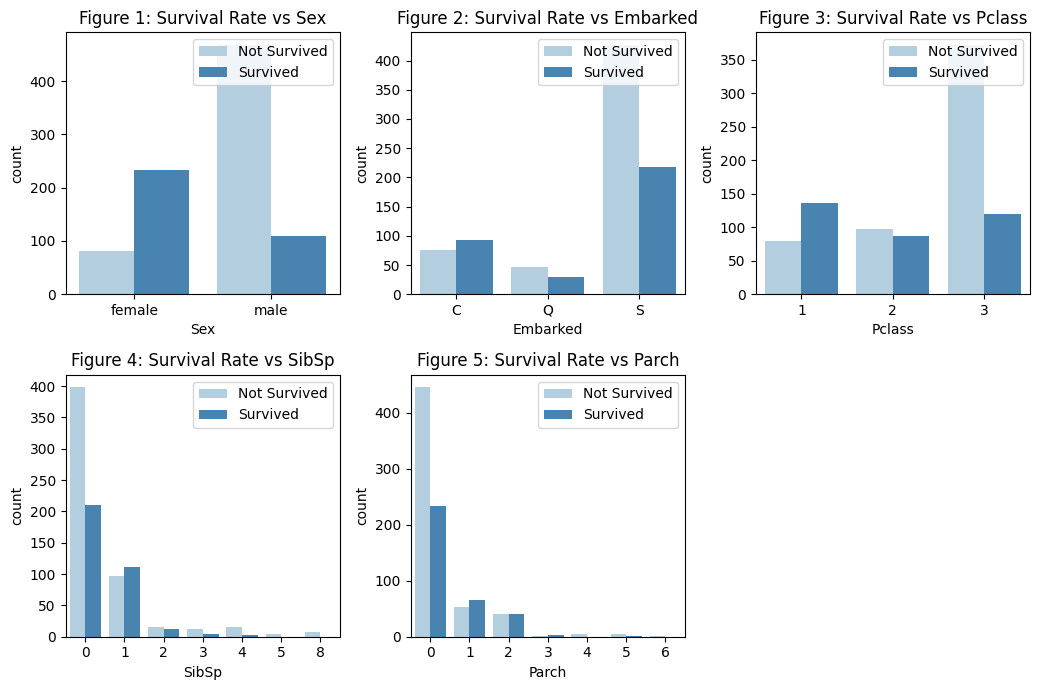

In [280]:
cols = ["Sex", "Embarked", "Pclass", "SibSp", "Parch"]

n_rows = 2
n_cols = 3

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))

for r in range(0, n_rows):
    for c in range(0, n_cols):
        i = r*n_cols + c #index to loop through list "cols"
        if i < len(cols):
            ax_i = ax[r, c]
            sns.countplot(data=train_df, x=cols[i], hue="Survived", palette="Blues", ax=ax_i)
            ax_i.set_title(f"Figure {i + 1}: Survival Rate vs {cols[i]}")
            ax_i.legend(title='', loc='upper right', labels=['Not Survived', 'Survived'])
ax.flat[-1].set_visible(False) #Remove the last subplot
plt.tight_layout()
plt.show()

**Observation:**
- **Survival Rate:**
    - Fig 1: Female survival rate > male
    - Fig 2: Most People embarked on Southampton, and also had the highest people not survived
    - Fig 3: 1st class higher survival rate
    - Fig 4: People going with 0 `SibsP` are mostly not survived, the number of passenger with 1-2 family members has a better chance of survival
    - Fig 5: People going with 0 `Parch` are mostly not survived

## **3.2 EDA for Numerical Features**

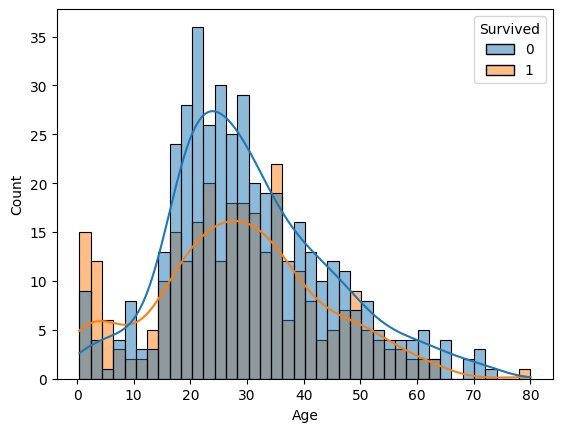

In [281]:
sns.histplot(data=train_df, x="Age", hue="Survived", bins = 40, kde=True);

- Majority passengers were from 18-40 ages
- Children had more chance to survive than other ages

In [282]:
train_df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


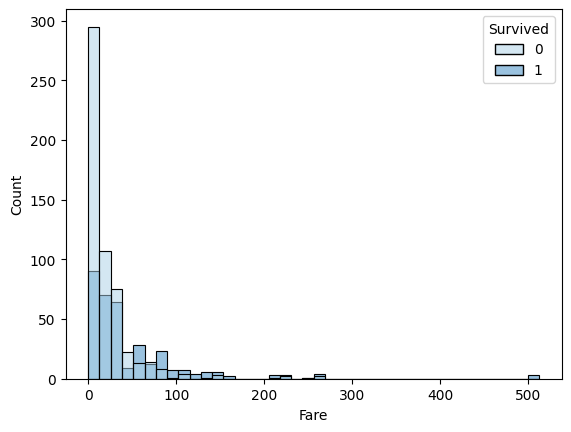

In [283]:
sns.histplot(data=train_df, x='Fare', hue = "Survived", bins = 40, palette = "Blues");

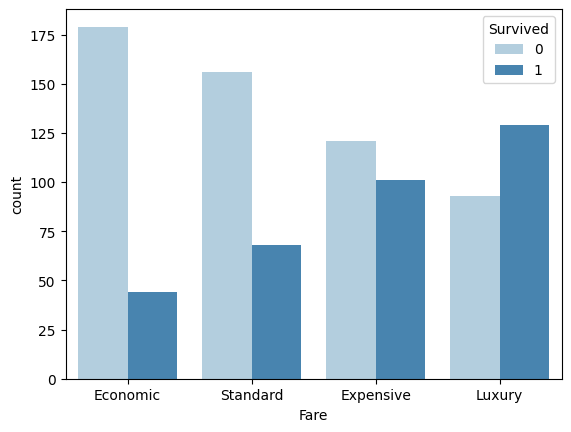

In [284]:
#To name for 0-25% quartile, 25-50, 50-75, 75-100

fare_categories = ['Economic', 'Standard', 'Expensive', 'Luxury']
quartile_data = pd.qcut(train_df["Fare"], 4, labels=fare_categories)

sns.countplot(x=quartile_data, hue=train_df["Survived"], palette="Blues");

# **4. Feature Engineering & Data Wrangling**

## **Name**

- Regular Expression (regex)

## **4.1 Feature Egineering**

In [285]:
train_df["Name"].tail(10)

,Name
PassengerId,
882,"Markun, Mr. Johann"
883,"Dahlberg, Miss. Gerda Ulrika"
884,"Banfield, Mr. Frederick James"
885,"Sutehall, Mr. Henry Jr"
886,"Rice, Mrs. William (Margaret Norton)"
887,"Montvila, Rev. Juozas"
888,"Graham, Miss. Margaret Edith"
889,"Johnston, Miss. Catherine Helen ""Carrie"""
890,"Behr, Mr. Karl Howell"


In [286]:
import re #RegEx

def extract_title(name):
    p = re.compile(r", ([\w\s]+)\.")
    return p.search(name).groups(1)[0].strip()

train_df["Title"] = train_df["Name"].apply(lambda name: extract_title(name))

In [287]:
train_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [288]:
test_df["Title"] = test_df["Name"].apply(lambda name: extract_title(name))

In [289]:
test_df["Title"].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [290]:
def group_title(title):
    if title in ["Mr", "Mrs", "Miss", "Master"]:
        return title
    elif title == "Ms":
        return "Miss"
    else:
        return "Others"

train_df["Title"] = train_df["Title"].apply(lambda title: group_title(title))
test_df["Title"] = test_df["Title"].apply(lambda title: group_title(title))

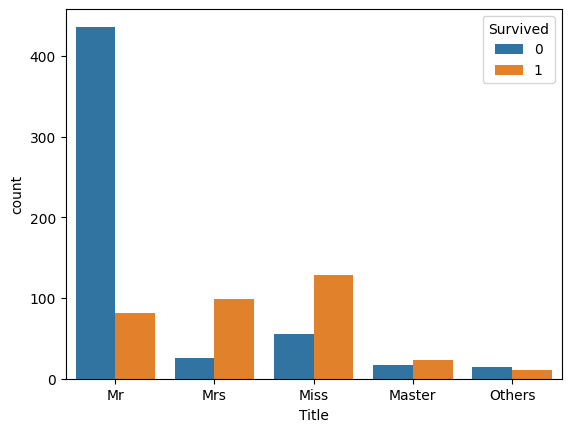

In [291]:
sns.countplot(data=train_df, x="Title", hue="Survived");

**Family**
- `SibSp`, `Parch`

In [292]:
train_df["Family_size"] = train_df['SibSp'].astype('int') + train_df['Parch'].astype('int') + 1

In [293]:
test_df["Family_size"] = test_df['SibSp'].astype('int') + test_df['Parch'].astype('int') + 1

In [294]:
train_df["Family_Cat"] = pd.cut(train_df["Family_size"], bins = [0,1,4,6,20], labels=["Solo", "Small", "Medium", "Large"]) # (0,1] (1,4] (4,6] (6,20]
test_df["Family_Cat"] = pd.cut(test_df["Family_size"], bins = [0,1,4,6,20], labels=["Solo", "Small", "Medium", "Large"]) # (0,1] (1,4] (4,6] (6,20]

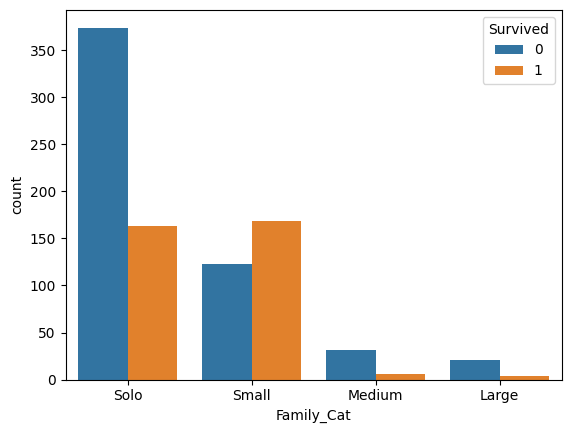

In [295]:
sns.countplot(data=train_df, x="Family_Cat", hue="Survived");

## **4.2 Data Wrangling**

In [296]:
num_features = ["Age", "Fare"]
cat_features = ["Sex", "Pclass", "Embarked", "Title", "Family_Cat"]
feature_cols = num_features + cat_features
print(feature_cols)

['Age', 'Fare', 'Sex', 'Pclass', 'Embarked', 'Title', 'Family_Cat']


In [297]:
def display_missing(df, feature_cols):
    n_rows = df.shape[0]
    for col in feature_cols:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            print(f"Col {col} has {missing_count*100/n_rows:.2f}% missing values.")

display_missing(train_df, feature_cols)
display_missing(test_df, feature_cols)

Col Age has 19.87% missing values.
Col Embarked has 0.22% missing values.
Col Age has 20.57% missing values.
Col Fare has 0.24% missing values.


### **4.2.1 Filling missing values**

#### Age
- Filling missing values with `median` of whole dataset

In [298]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    category
 7   Parch        891 non-null    category
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
 12  Title        891 non-null    object  
 13  Family_size  891 non-null    int64   
 14  Family_Cat   891 non-null    category
dtypes: category(7), float64(2), int64(2), object(4)
memory usage: 70.1+ KB


In [299]:
age_by_sex_pclass = train_df.groupby(["Sex", "Pclass"])["Age"].median()

/tmp/ipykernel_8148/3415749811.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_sex_pclass = train_df.groupby(["Sex", "Pclass"])["Age"].median()


In [300]:
age_by_sex_pclass

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [301]:
# Filling missing values in Age with the median of Sex and Pclass groups

train_df["Age"] = train_df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_8148/749385381.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df["Age"] = train_df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))


In [302]:
test_df["Age"] = test_df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_8148/2277889828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df["Age"] = test_df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))


In [303]:
display_missing(train_df, feature_cols)
display_missing(test_df, feature_cols)

Col Embarked has 0.22% missing values.
Col Fare has 0.24% missing values.


In [304]:
X = train_df[feature_cols]
y = train_df['Survived']

In [305]:
X_test = test_df[feature_cols]

In [306]:
# preprocess pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [307]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

In [308]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Age', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Pclass', 'Embarked', 'Title',
                                  'Family_Cat'])])

In [309]:
X = preprocessor.transform(X) # X -> X_train, X_val

In [310]:
X_test = preprocessor.transform(X_test)

# **5. Model Training**

## **5.1 Logistic regression from scratch**

In [311]:
X_scratch = np.hstack((np.ones((X.shape[0], 1)), X))

In [312]:
y_scratch = y.to_numpy()

In [313]:
from sklearn.model_selection import train_test_split

test_size = 0.2
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(X_scratch, y_scratch,
                                                  test_size=test_size,
                                                  shuffle=is_shuffle)

In [314]:
X_train.shape, y_train.shape

((712, 20), (712,))

In [315]:
theta.shape

(20,)

In [316]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def predict(X, theta):
    z = np.dot(X, theta)
    return sigmoid_function(z)

def compute_loss(y, y_hat):
    return (
        -y * \
        np.log(y_hat) - (1 - y) * \
        np.log(1 - y_hat)
    ).mean()

def compute_gradient(X, y, y_hat):
    gradient = np.dot(X.T, y_hat - y) / y.size
    return gradient

def update_parameters(theta, gradient, lr = 0.01):
    theta -= lr * gradient
    return theta

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    acc = (y_hat == y).mean()
    return acc

In [317]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []
epochs = 1000
lr = 0.01
batch_size = 16

np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        y_hat = predict(X_i, theta)

        train_loss = compute_loss(y_i, y_hat)

        gradient = compute_gradient(X_i, y_i, y_hat)

        theta = update_parameters(theta, gradient, lr)

        train_batch_losses.append(train_loss)

        train_acc = compute_accuracy(X_i, y_i, theta)
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val, theta)
        val_loss = compute_loss(y_val, y_val_hat)
        val_batch_losses.append(val_loss)

        val_acc = compute_accuracy(X_val, y_val, theta)
        val_batch_accs.append(val_acc)

    train_batch_losses = np.array(train_batch_losses).mean()
    val_batch_losse = np.array(val_batch_losses).mean()
    train_batch_accs = np.array(train_batch_accs).mean()
    val_batch_accs = np.array(val_batch_accs).mean()

    train_accs.append(train_batch_accs)
    train_losses.append(train_batch_losses)
    val_accs.append(val_batch_accs)
    val_losses.append(val_batch_losse)

    print(f"\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_losses:.3f}\tValidation loss: {val_batch_losse:.3f}")


EPOCH 1:	Training loss: 1.439	Validation loss: 1.326

EPOCH 2:	Training loss: 1.025	Validation loss: 0.978

EPOCH 3:	Training loss: 0.783	Validation loss: 0.780

EPOCH 4:	Training loss: 0.658	Validation loss: 0.682

EPOCH 5:	Training loss: 0.594	Validation loss: 0.634

EPOCH 6:	Training loss: 0.559	Validation loss: 0.609

EPOCH 7:	Training loss: 0.539	Validation loss: 0.595

EPOCH 8:	Training loss: 0.525	Validation loss: 0.586

EPOCH 9:	Training loss: 0.516	Validation loss: 0.579

EPOCH 10:	Training loss: 0.509	Validation loss: 0.575

EPOCH 11:	Training loss: 0.504	Validation loss: 0.571

EPOCH 12:	Training loss: 0.499	Validation loss: 0.567

EPOCH 13:	Training loss: 0.495	Validation loss: 0.564

EPOCH 14:	Training loss: 0.492	Validation loss: 0.561

EPOCH 15:	Training loss: 0.489	Validation loss: 0.558

EPOCH 16:	Training loss: 0.486	Validation loss: 0.555

EPOCH 17:	Training loss: 0.483	Validation loss: 0.552

EPOCH 18:	Training loss: 0.480	Validation loss: 0.550

EPOCH 19:	Training

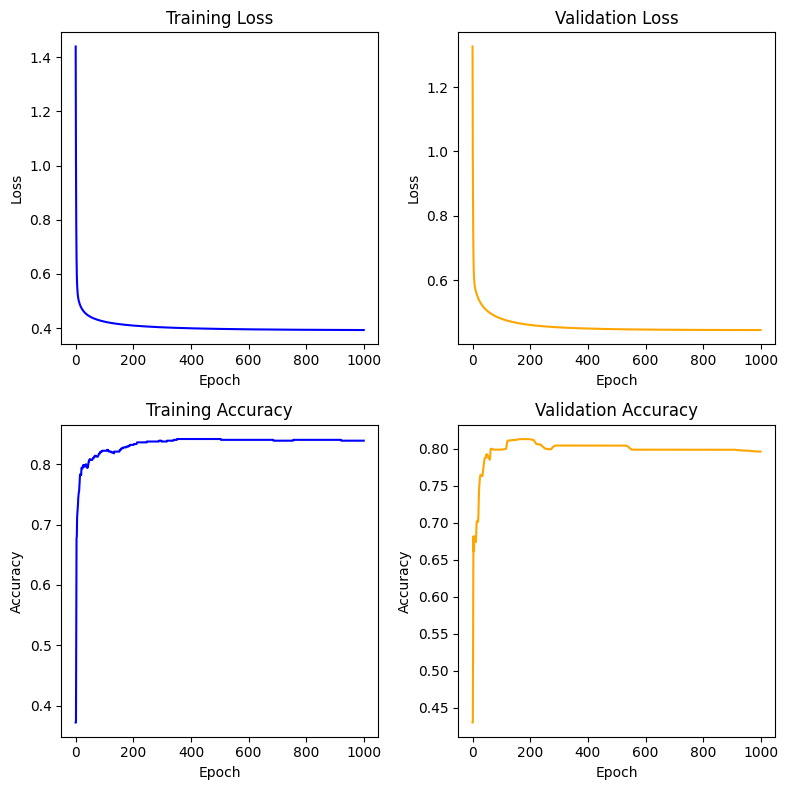

In [318]:
metrics = {
    "Training Loss": train_losses,
    "Validation Loss": val_losses,
    "Training Accuracy": train_accs,
    "Validation Accuracy": val_accs
}

n_rows = 2
n_cols = 2

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))

for r in range(0, n_rows):
    for c in range(0, n_cols):
        i = r*n_cols + c #index to loop through list "cols"
        if i < len(metrics):
            key = list(metrics.keys())[i]
            ax_i = ax[r, c]
            ax_i.plot(metrics[key], color = "Blue" if "Training" in key else "orange")
            ax_i.set(xlabel="Epoch", ylabel="Loss" if "Loss" in key else "Accuracy")
            ax_i.set_title(key)
plt.tight_layout()
plt.show()

## **5.2 Scikit-Learn**

In [319]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [320]:
# binary classification
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, classification_report

log_red = LogisticRegression(solver='liblinear', max_iter=1000)
log_red.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [321]:
log_red.score(X_val, y_val)

0.8212290502793296

In [322]:
y_pred = log_red.predict(X_val)

In [323]:
precision_score(y_val, y_pred), recall_score(y_val, y_pred)

(0.8309859154929577, 0.7468354430379747)

In [324]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       100
           1       0.83      0.75      0.79        79

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.82      0.82      0.82       179



In [325]:
poly = PolynomialFeatures(degree=3)
poly_features_X_train = poly.fit_transform(X_train)
poly_features_X_val = poly.transform(X_val)

In [326]:
poly_log_red = LogisticRegression(solver='liblinear', max_iter=1000)
poly_log_red.fit(poly_features_X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [327]:
poly_log_red.score(poly_features_X_val, y_val)

0.7821229050279329

In [328]:
# Decision Tree
decision_tree = DecisionTreeClassifier(criterion='entropy', max_depth = 5, random_state=2026)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=2026)

In [329]:
decision_tree.score(X_val, y_val)

0.8324022346368715

## **5.3 Cross-Validation**

In [330]:
from sklearn.model_selection import cross_val_score

In [331]:
log_reg_cv = LogisticRegression(solver='liblinear', max_iter=1000)
dt_cv = DecisionTreeClassifier(criterion='entropy', max_depth = 5, random_state=2026)

lr_scores = cross_val_score(log_reg_cv, X, y, scoring='accuracy', cv=5)

In [332]:
lr_scores.mean(), lr_scores.std()

(np.float64(0.826031008725127), np.float64(0.020466357172416235))

In [333]:
dt_scores = cross_val_score(dt_cv, X, y, scoring='accuracy', cv=5)

In [334]:
dt_scores.mean(), dt_scores.std()

(np.float64(0.8137216747222397), np.float64(0.014388618786467437))

# **5.4 Baseline Model Comparison**

In [335]:
!pip install xgboost

In [336]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

seed = 2026

models = [
    LinearSVC(max_iter=12000, random_state = seed),
    SVC(random_state=seed),
    KNeighborsClassifier(metric='minkowski', p=2),
    LogisticRegression(solver='liblinear', max_iter=1000),
    DecisionTreeClassifier(random_state=seed),
    RandomForestClassifier(random_state=seed),
    ExtraTreesClassifier(),
    AdaBoostClassifier(),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed)
]

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [03:49:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [03:49:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [03:49:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [03:49:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:

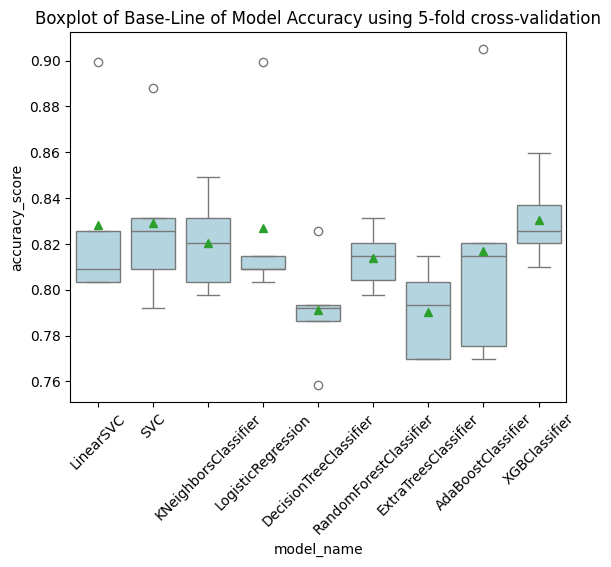

,Mean,Standared Deviation
model_name,,
XGBClassifier,0.830550,0.018924
SVC,0.829339,0.036358
LinearSVC,0.828203,0.040875
LogisticRegression,0.827079,0.040646
KNeighborsClassifier,0.820394,0.020932
AdaBoostClassifier,0.816961,0.054190
RandomForestClassifier,0.813703,0.013213
DecisionTreeClassifier,0.791243,0.023986
ExtraTreesClassifier,0.790120,0.020139


In [337]:
from sklearn.model_selection import StratifiedKFold

def generate_baseline_results(models, X, y, metrics, cv=5, plot_results=False):
    # defind K-fold:
    kfold = StratifiedKFold(cv, shuffle=True, random_state=seed)
    entries = []
    for model in models:
        model_name = model.__class__.__name__
        scores = cross_val_score(model, X, y, scoring=metrics, cv=kfold)
        for fold_idx, score in enumerate(scores):
            entries.append((model_name, fold_idx, score))

    cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_id', 'accuracy_score'])

    if plot_results:
        sns.boxplot(x='model_name', y='accuracy_score', data=cv_df, color='lightblue', showmeans=True)
        plt.title("Boxplot of Base-Line of Model Accuracy using 5-fold cross-validation")
        plt.xticks(rotation=45)
        plt.show()
    # Summary results
    mean = cv_df.groupby('model_name')['accuracy_score'].mean()
    std = cv_df.groupby('model_name')['accuracy_score'].std()

    baseline_results = pd.concat([mean, std], axis=1, ignore_index=True)
    baseline_results.columns = ['Mean', 'Standared Deviation']

    # sort by accuracy
    baseline_results.sort_values(by=['Mean'], ascending=False, inplace=True)
    return baseline_results

generate_baseline_results(models, X, y, metrics='accuracy', cv=5, plot_results=True)